# Evolution of Cooperation Simulation

## Introduction

Cooperation is a central problem in evolutionary dynamics and social systems.
Although defection can yield higher short-term rewards, cooperative behavior
is widely observed in biological and social environments.

Evolutionary game theory provides a framework to study this phenomenon.
In particular, the Prisoner's Dilemma illustrates the tension between
individual incentives and collective benefit.

This simulation explores how cooperation evolves in a population of agents
interacting on a spatial lattice.

---

## Model

Agents are located on a two-dimensional L × L grid.

Each agent adopts one of two strategies:

C : Cooperation  
D : Defection

At each time step:

1. An agent interacts with a randomly selected neighbor.
2. Both agents receive payoffs based on the payoff matrix.
3. If the neighbor obtains a higher payoff, the agent imitates the neighbor's strategy.

The interaction follows the Prisoner's Dilemma payoff structure:

    |      | C | D |
    |------|---|---|
    | C | R | S |
    | D | T | P |

Typical parameters used in the simulation:

R = 3  (reward for mutual cooperation)  
S = 0  (sucker's payoff)  
T = 5  (temptation to defect)  
P = 1  (punishment for mutual defection)

Agents interact with their four nearest neighbors and periodic boundary
conditions are applied.

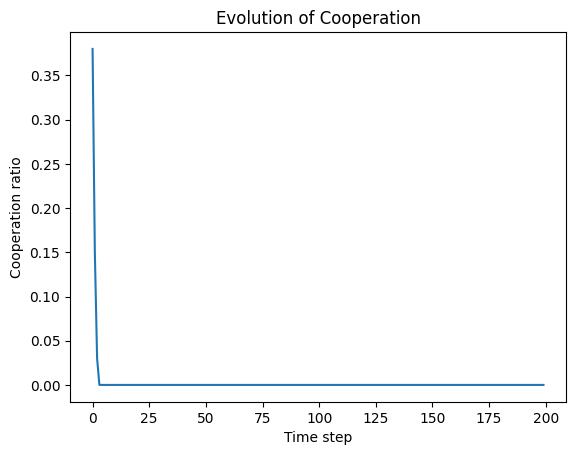

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

N = 100
steps = 200

strategies = np.random.choice(["C","D"], size=N)

cooperation_ratio = []

def payoff(a,b):
    if a == "C" and b == "C":
        return 3
    elif a == "C" and b == "D":
        return 0
    elif a == "D" and b == "C":
        return 5
    else:
        return 1

for step in range(steps):
    new_strategies = strategies.copy()

    for i in range(N):

        opponent = random.randint(0, N-1)

        p1 = payoff(strategies[i], strategies[opponent])
        p2 = payoff(strategies[opponent], strategies[i])

        if p2 > p1:
            new_strategies[i] = strategies[opponent]

    strategies = new_strategies

    cooperation_ratio.append(np.sum(strategies=="C")/N)

plt.plot(cooperation_ratio)
plt.xlabel("Time step")
plt.ylabel("Cooperation ratio")
plt.title("Evolution of Cooperation")
plt.show()
    

In [ ]:
空間内で

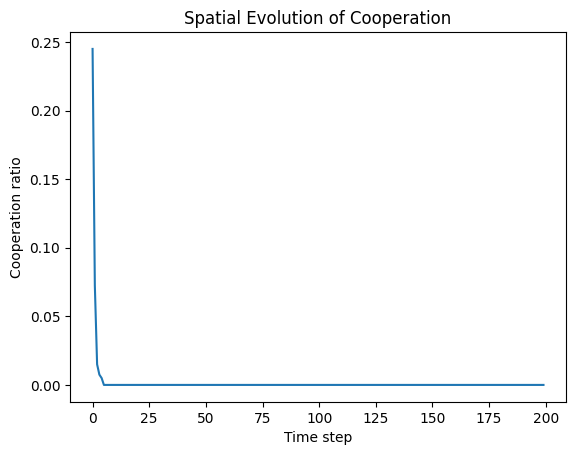

In [14]:
L = 20
N = L * L
steps = 200

strategies = np.random.choice(["C","D"], size=(L,L))

cooperation_ratio = []

def payoff(a,b):
    if a == "C" and b == "C":
        return 3
    elif a == "C" and b == "D":
        return 0
    elif a == "D" and b == "C":
        return 5
    else:
        return 1

for step in range(steps):

    new_strategies = strategies.copy()

    for i in range(L):
        for j in range(L):

            neighbors = [
                ((i+1)%L,j),
                ((i-1)%L,j),
                (i,(j+1)%L),
                (i,(j-1)%L)
            ]

            ni,nj = random.choice(neighbors)

            p1 = payoff(strategies[i,j], strategies[ni,nj])
            p2 = payoff(strategies[ni,nj], strategies[i,j])

            if p2 > p1:
                new_strategies[i,j] = strategies[ni,nj]

    strategies = new_strategies
    cooperation_ratio.append(np.sum(strategies=="C")/N)

plt.plot(cooperation_ratio)
plt.xlabel("Time step")
plt.ylabel("Cooperation ratio")
plt.title("Spatial Evolution of Cooperation")
plt.show()       

In [ ]:
returnを変える

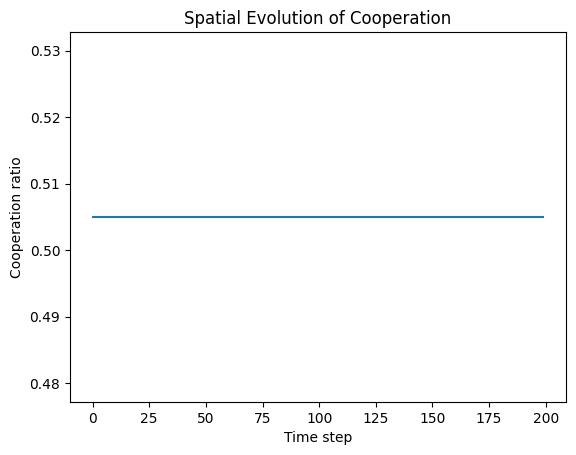

In [13]:
L = 20
N = L * L
steps = 200

strategies = np.random.choice(["C","D"], size=(L,L))

cooperation_ratio = []

def payoff(a,b):
    if a == "C" and b == "C":
        return 5
    elif a == "C" and b == "D":
        return 2
    elif a == "D" and b == "C":
        return 2
    else:
        return 1

for step in range(steps):

    new_strategies = strategies.copy()

    for i in range(L):
        for j in range(L):

            neighbors = [
                ((i+1)%L,j),
                ((i-1)%L,j),
                (i,(j+1)%L),
                (i,(j-1)%L)
            ]

            ni,nj = random.choice(neighbors)

            p1 = payoff(strategies[i,j], strategies[ni,nj])
            p2 = payoff(strategies[ni,nj], strategies[i,j])

            if p2 > p1:
                new_strategies[i,j] = strategies[ni,nj]

    strategies = new_strategies
    cooperation_ratio.append(np.sum(strategies=="C")/N)

plt.plot(cooperation_ratio)
plt.xlabel("Time step")
plt.ylabel("Cooperation ratio")
plt.title("Spatial Evolution of Cooperation")
plt.show()       

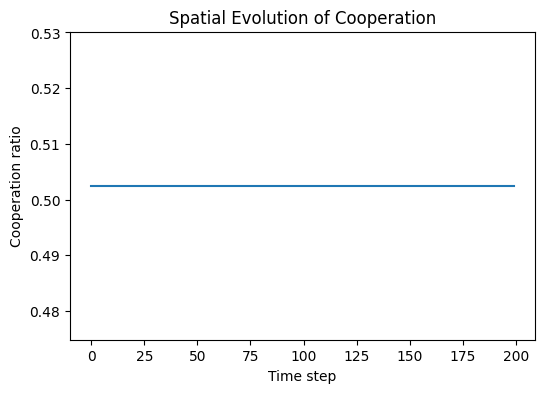

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Parameters
# -----------------------------

L = 20
N = L * L
steps = 200

# payoff parameters
R = 5   # reward (C,C)
S = 2   # sucker (C,D)
T = 2   # temptation (D,C)
P = 1   # punishment (D,D)

# -----------------------------
# Initialize strategies
# -----------------------------

strategies = np.random.choice(["C","D"], size=(L,L))

cooperation_ratio = []

# -----------------------------
# Payoff function
# -----------------------------

def payoff(a,b):

    if a == "C" and b == "C":
        return R

    elif a == "C" and b == "D":
        return S

    elif a == "D" and b == "C":
        return T

    else:
        return P

# -----------------------------
# Simulation
# -----------------------------

for step in range(steps):

    new_strategies = strategies.copy()

    for i in range(L):
        for j in range(L):

            neighbors = [
                ((i+1)%L,j),
                ((i-1)%L,j),
                (i,(j+1)%L),
                (i,(j-1)%L)
            ]

            ni,nj = random.choice(neighbors)

            p1 = payoff(strategies[i,j], strategies[ni,nj])
            p2 = payoff(strategies[ni,nj], strategies[i,j])

            if p2 > p1:
                new_strategies[i,j] = strategies[ni,nj]

    strategies = new_strategies

    cooperation_ratio.append(np.sum(strategies=="C")/N)

# -----------------------------
# Plot result
# -----------------------------

plt.figure(figsize=(6,4))

plt.plot(cooperation_ratio)

plt.xlabel("Time step")
plt.ylabel("Cooperation ratio")
plt.title("Spatial Evolution of Cooperation")

plt.show()

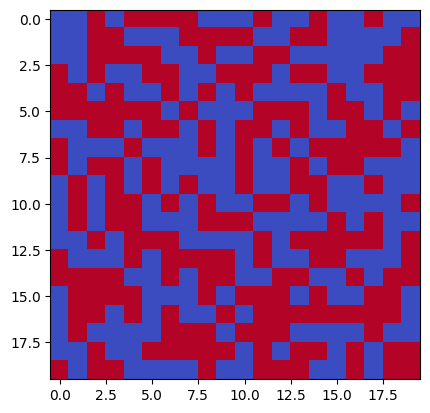

In [18]:
plt.imshow(strategies == "C", cmap="coolwarm")

## Discussion

The simulation illustrates how spatial structure can support the emergence
of cooperation. In well-mixed populations, defection often dominates because
it provides a higher payoff against cooperators.

However, in spatial systems cooperative agents can form clusters and support
each other through repeated local interactions. These clusters protect
cooperators from invasion by defectors and allow cooperation to persist.

This model is related to research areas such as evolutionary game theory,
agent-based modeling, and complex systems.

Possible extensions include:

- alternative network structures
- stochastic update rules
- additional strategies
- reinforcement learning agents